In [1]:
import numpy as np
import matplotlib.pyplot as plt
from DataLoader import prepare_stokes_data
from ME_utils import niris_MEsinglet, get_noise
from pathlib import Path
import pandas as pd

## Chi-Square Fix in ME Inversion (`ME_utils.py`)

The Milne-Eddington inversion fits 9 free parameters $(B, \theta, \chi, \eta_0, \Delta\lambda_D, a, \lambda_0, B_0, B_1)$ to observed Stokes profiles $(I, Q, U, V)$ using Levenberg-Marquardt optimization via `lmfit`.

### Bugs Fixed

#### 1. Incorrect weights passed to `lmfit` in `niris_mefit_lmfit`

The noise for each Stokes parameter is estimated as `sigma_k = get_noise(data[:,k])`. Previously, weights were computed as $1/\sigma^2$ and passed directly to `lmfit`. Since `lmfit` squares its `weights` argument internally, the optimizer was minimizing:

$$\chi^2_{\text{wrong}} = \sum_i \frac{r_i^2}{\sigma_k^4}$$

instead of the correct weighted least squares objective:

$$\chi^2_{\text{correct}} = \sum_i \frac{r_i^2}{\sigma_k^2}$$

The fix was to pass $1/\sigma$ to `lmfit` to account for internal squaring.

#### 2. Incorrect denominator in reduced chi-square calculation

The reduced chi-square was normalized by $4n$ (total number of data points) rather than $4n - 9$ (degrees of freedom, accounting for the 9 free inversion parameters):

$$\chi^2_{\text{old}} = \frac{1}{4n} \sum_i \frac{r_i^2}{\sigma_k^2}$$

$$\chi^2_{\text{new}} = \frac{1}{4n - 9} \sum_i \frac{r_i^2}{\sigma_k^2}$$

#### 3. Double normalization in `process_single_row`

`niris_mefit_lmfit` already returns a reduced chi-square, but `process_single_row` divided it by $4n$ a second time before storing:
```python
# Old (wrong)
row_chisqa[ypos] = chisq / (len(s) * 4)

# New (correct)
row_chisqa[ypos] = chisq
```

# Inspecting ME Labels

In [2]:
def get_labels (timepoint, which_labels="old"):
    # Construct path
    if which_labels == "old":
        suffix = ""
        if timepoint[:6] == "240519":
            suffix = "_02"
        elif timepoint[:6] == "240728":
            suffix = "_03"
        file_path = f"../../../new_data{suffix}_trainset"
    else:
        file_path = "new_ME_labels"
    
    # Get data
    with np.load(f"{file_path}/gst_niris_inv_20{timepoint}.npz", allow_pickle=True) as data:
        parameters = data['data']
        chi2 = data['chisqa']
    
    return parameters, chi2

def get_stokes (timepoint):
    # Construct path
    suffix = ""
    if timepoint[:6] == "240519":
        suffix = "_02"
    elif timepoint[:6] == "240728":
        suffix = "_03"
    file_path = f"../../../new_data{suffix}_trainset"
    
    data, wavelengths, hdr = prepare_stokes_data(f"{file_path}/cals_{timepoint}.fts")
    return data, wavelengths

def store_reconstruction(timepoint, which_labels="old"):
    # Get parameters
    params, _ = get_labels(timepoint, which_labels)
    
    # Get dlambda and observed Stokes data
    stokes_data, dlambda = get_stokes(timepoint)
    stokes_data = stokes_data.cpu().numpy()
    dlambda = dlambda.numpy()

    # Tile for niris_MEsinglet
    x = np.tile(dlambda, 4)
    nx, ny = params.shape[:2]
    n_lambda = len(dlambda)
    reconstructed = np.zeros((nx, ny, n_lambda, 4))

    for i in range(nx):
        for j in range(ny):
            p = params[i, j, :9]
            profile = niris_MEsinglet(x, *p)
            reconstructed[i, j] = profile.reshape(4, -1).T

    # Calculate per-pixel reduced chi-square between observed and reconstructed
    # using the same noise estimation as niris_mefit_lmfit
    chisq_map = np.zeros((nx, ny))
    n_dof = 4 * n_lambda - 9
    for i in range(nx):
        for j in range(ny):
            obs = stokes_data[i, j]  # shape (n_lambda, 4)
            rec = reconstructed[i, j]
            # Build noise weights the same way as niris_mefit_lmfit
            weights_sigma = np.array([get_noise(obs[:, k]) for k in range(4)])  # shape (4,)
            residuals = (obs - rec) ** 2  # shape (n_lambda, 4)
            chisq_map[i, j] = np.sum(residuals / weights_sigma[None, :] ** 2) / n_dof

    # Save as npz
    filename = f"new_ME_labels/reconstructed_{timepoint}_{which_labels}"
    np.savez(filename,
             reconstructed=reconstructed,   # (nx, ny, n_lambda, 4)
             chisq_map=chisq_map,           # (nx, ny)
             wavelengths=dlambda)           # (n_lambda,)

    print(f"Saved to {filename}.npz")
    return reconstructed, chisq_map

def get_reconstruction(timepoint, which_labels="old"):
    with np.load(f"new_ME_labels/reconstructed_{timepoint}_{which_labels}.npz") as data:
        reconstructed = data['reconstructed']
        chisq_map = data['chisq_map']
        wavelengths = data['wavelengths']
    return reconstructed, chisq_map, wavelengths

def chisq_stats(chisq_map):
    f = chisq_map.flatten()
    return {
        "Mean"        : f.mean(),
        "Median"      : np.median(f),
        "Min"         : f.min(),
        "Max"         : f.max(),
        "Std dev"     : f.std(),
        "25th pct"    : np.percentile(f, 25),
        "75th pct"    : np.percentile(f, 75),
        "95th pct"    : np.percentile(f, 95),
        "99th pct"    : np.percentile(f, 99),
        "% χ² < 2"    : 100 * np.mean(f < 2),
        "% χ² < 5"    : 100 * np.mean(f < 5),
        "% χ² > 10"   : 100 * np.mean(f > 10),
    }

def df_stats (timepoint):
    _, chisq_old, _ = get_reconstruction(timepoint, which_labels="old")
    _, chisq_new, _ = get_reconstruction(timepoint, which_labels="new")
    df = pd.DataFrame({"Old ME Inversion": chisq_stats(chisq_old), "New ME Inversion": chisq_stats(chisq_new)})
    return df

def df_stats_styled(timepoint):
    df = df_stats(timepoint)
    
    # For most stats, lower is better — but for % χ² < 2 and % χ² < 5, higher is better
    higher_is_better = {"% χ² < 2", "% χ² < 5"}
    
    def highlight_better(row):
        styles = ["", ""]
        old, new = row["Old ME Inversion"], row["New ME Inversion"]
        if row.name in higher_is_better:
            better_col = 0 if old > new else 1
        else:
            better_col = 0 if old < new else 1
        styles[better_col] = "font-weight: bold; color: green"
        return styles
    
    return df.style.apply(highlight_better, axis=1)

def plot_chisq_comparison(timepoint, vmax=10):
    old_recon, old_chisq, _ = get_reconstruction(timepoint, which_labels="old")
    new_recon, new_chisq, _ = get_reconstruction(timepoint, which_labels="new")

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    im = axs[0].imshow(old_chisq, origin='lower', cmap='inferno', vmin=0, vmax=vmax)
    axs[0].set_title('Old ME Inversion χ²')
    
    axs[1].imshow(new_chisq, origin='lower', cmap='inferno', vmin=0, vmax=vmax)
    axs[1].set_title('New ME Inversion χ²')
    
    fig.colorbar(im, ax=axs, label='Reduced χ²', shrink=0.8)
    plt.suptitle(f"Timepoint: {timepoint}")
    plt.show()

In [25]:
timepoints = ["240725_163222", "240725_184339", "240519_213027", "240519_222709", "240728_174037", "240728_175559"]
for timepoint in timepoints:
    store_reconstruction(timepoint, which_labels="old")
    store_reconstruction(timepoint, which_labels="new")

Saved to new_ME_labels/reconstructed_240725_163222_old.npz
Saved to new_ME_labels/reconstructed_240725_163222_new.npz
Saved to new_ME_labels/reconstructed_240725_184339_old.npz
Saved to new_ME_labels/reconstructed_240725_184339_new.npz
Saved to new_ME_labels/reconstructed_240519_213027_old.npz
Saved to new_ME_labels/reconstructed_240519_213027_new.npz
Saved to new_ME_labels/reconstructed_240519_222709_old.npz
Saved to new_ME_labels/reconstructed_240519_222709_new.npz
Saved to new_ME_labels/reconstructed_240728_174037_old.npz
Saved to new_ME_labels/reconstructed_240728_174037_new.npz
Saved to new_ME_labels/reconstructed_240728_175559_old.npz
Saved to new_ME_labels/reconstructed_240728_175559_new.npz


In [3]:
timepoints = ["240725_163222", "240725_184339", "240519_213027", "240519_222709", "240728_174037", "240728_175559"]
ND1, ND2, N2D1, N2D2, N3D1, N3D2 = timepoints

# Reconstruction Comparison

The old and new $\chi^2$ maps are not directly comparable, since the old optimizer was minimizing $\sum_i r_i^2/\sigma^4$ rather than the correct $\sum_i r_i^2/\sigma^2$. To put both on equal footing, the $\chi^2$ maps below were recomputed by comparing the observed Stokes profiles against profiles reconstructed from the saved inversion parameters using `niris_MEsinglet`, for consistency.

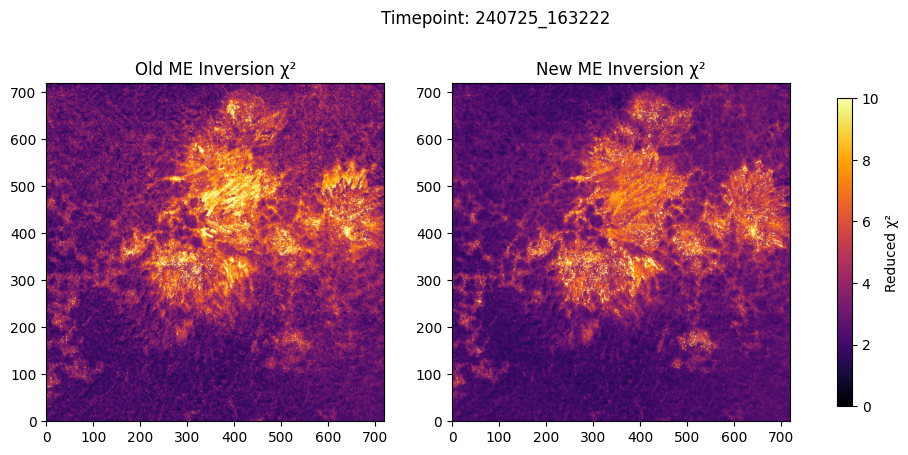

,Old ME Inversion,New ME Inversion
Mean,3.783058,3.398317
Median,3.232266,2.832099
Min,0.863207,1.014020
Max,185.867597,26.410960
Std dev,2.007376,1.769629
25th pct,2.430967,2.250085
75th pct,4.586012,4.013945
95th pct,7.511737,6.610208
99th pct,11.066541,10.477565
% χ² < 2,11.377894,13.899306


In [4]:
timepoint = ND1
plot_chisq_comparison(timepoint, vmax=10)
df_stats_styled(timepoint)

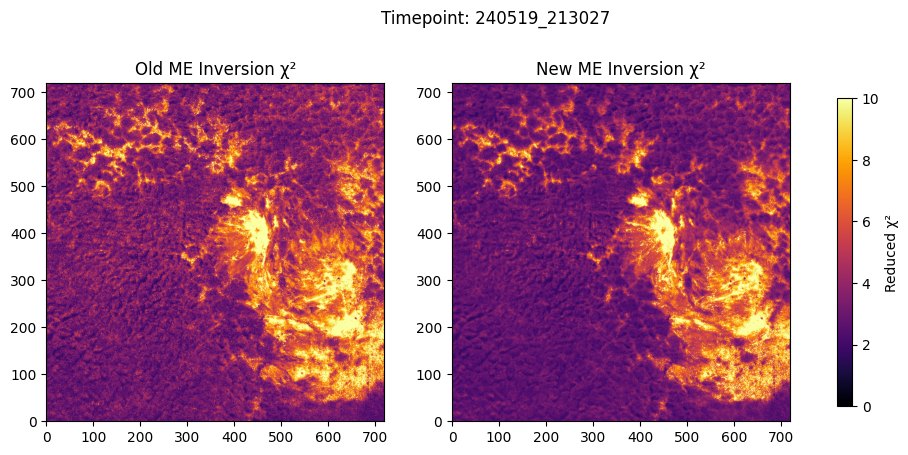

,Old ME Inversion,New ME Inversion
Mean,4.547744,3.982688
Median,3.864457,3.186048
Min,1.049690,1.070138
Max,1273.117565,46.201764
Std dev,3.040018,2.144976
25th pct,3.056966,2.667828
75th pct,5.329476,4.591867
95th pct,9.034981,8.269511
99th pct,12.754484,12.107783
% χ² < 2,2.383295,2.116512


In [5]:
timepoint = N2D1
plot_chisq_comparison(timepoint, vmax=10)
df_stats_styled(timepoint)

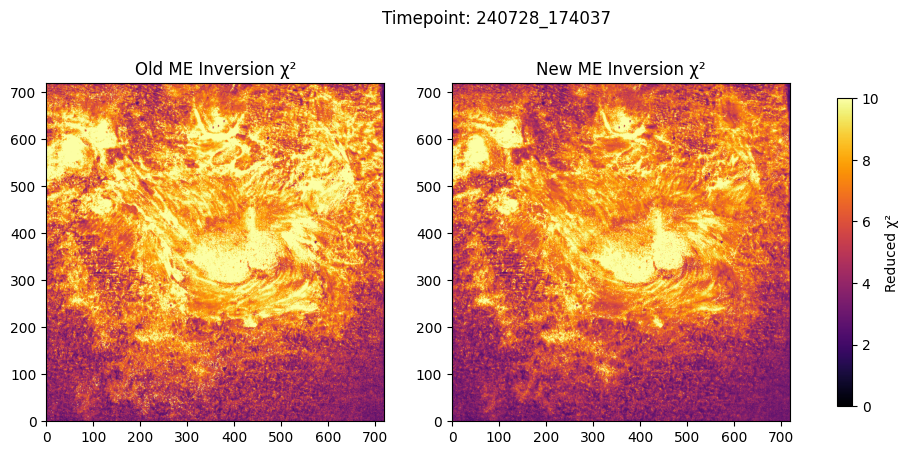

,Old ME Inversion,New ME Inversion
Mean,7.375646,6.573373
Median,7.075462,6.326896
Min,1.656958,1.781524
Max,187.840085,37.412837
Std dev,3.159717,2.675931
25th pct,5.329480,4.718783
75th pct,8.762494,7.788317
95th pct,12.321190,10.951290
99th pct,17.915290,16.220736
% χ² < 2,0.011188,0.007137


In [6]:
timepoint = N3D1
plot_chisq_comparison(timepoint, vmax=10)
df_stats_styled(timepoint)